In [1]:
# ── CELL 1: Mount Drive + Install + Imports ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-image opencv-python-headless

import os, re, cv2, json, warnings, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter
from skimage.filters import frangi as skimage_frangi
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────
OUTPUT_ROOT    = '/content/drive/MyDrive/DorsalVeinProject'
DATASET_ROOT   = f'{OUTPUT_ROOT}/dorsalhandveins'
PROCESSED_DIR  = f'{OUTPUT_ROOT}/processed_v2'
STRUCTURED_DIR = f'{OUTPUT_ROOT}/dataset_structured'
RESULTS_DIR    = f'{OUTPUT_ROOT}/results'
OUTPUT_SIZE    = (128, 128)
DBS            = [1, 2]

for d in [PROCESSED_DIR, STRUCTURED_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('✓ Drive mounted and imports ready')
print(f'  Dataset : {DATASET_ROOT}')
print(f'  Output  : {OUTPUT_ROOT}')

Mounted at /content/drive
✓ Drive mounted and imports ready
  Dataset : /content/drive/MyDrive/DorsalVeinProject/dorsalhandveins
  Output  : /content/drive/MyDrive/DorsalVeinProject


In [16]:
# =========================================================================
# CELL 2: PIPELINE FUNCTIONS (SQUARE ROI UPGRADE)
# =========================================================================
import os
import re
import json
import random
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_largest_inscribed_circle(mask):
    """
    Distance transform method:
    Each pixel = distance to nearest background pixel.
    Peak = centre of largest circle that fits inside the mask.
    Returns (cx, cy, radius)
    """
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _, radius, _, center = cv2.minMaxLoc(dist)
    return int(center[0]), int(center[1]), int(radius)


def extract_square_roi(gray, debug=False):
    """
    Updated Paper Pipeline:
    1. Gaussian blur
    2. Otsu threshold
    3. Morphological closing → hand mask
    4. Largest inscribed circle via distance transform
    5. Calculate and crop maximum inscribed square (side = r * sqrt(2))
    6. Resize to OUTPUT_SIZE
    """
    h, w = gray.shape

    # Step 1 + 2: Thresholding
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Step 3: Morphological closing to build the solid hand mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return (None, None, False, {}) if debug else (None, None, False)

    hand_mask = np.zeros_like(gray)
    cv2.fillPoly(hand_mask, [max(contours, key=cv2.contourArea)], 255)

    # Step 4: Inscribed circle extraction
    cx, cy, radius = get_largest_inscribed_circle(hand_mask)
    if radius < min(h, w) // 8:
        return (None, None, False, {}) if debug else (None, None, False)

    # Step 5: Convert circle to maximum inscribed square (No black masking!)
    # Half-side length calculation: (r * sqrt(2)) / 2 = r * 0.7071
    half_s = int(radius * 0.7071)

    x1 = max(0, cx - half_s); y1 = max(0, cy - half_s)
    x2 = min(w, cx + half_s); y2 = min(h, cy + half_s)

    # Direct pure crop out of raw grayscale image
    roi_crop = gray[y1:y2, x1:x2]
    if roi_crop.size == 0:
        return (None, None, False, {}) if debug else (None, None, False)

    # Step 6: Uniform resizing
    roi = cv2.resize(roi_crop, OUTPUT_SIZE, interpolation=cv2.INTER_LANCZOS4)

    if debug:
        return roi, (cx, cy, radius, half_s), True, {
            'binary': binary, 'closed': closed, 'hand_mask': hand_mask
        }
    return roi, (cx, cy, radius, half_s), True


def enhance_blackhat(roi):
    """Isolates dark veins into bright white structures across pure skin patches."""
    # Step 1: Initial contrast adjustment
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(roi)

    # Step 2: Extract dark elements using a wide morphological kernel
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
    bh = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

    # Step 3: Gentle smoothing to blend high-frequency edge textures
    bh_blurred = cv2.GaussianBlur(bh, (5, 5), 0)

    # Step 4: Min-Max normalization
    return cv2.normalize(bh_blurred, None, 0, 255, cv2.NORM_MINMAX)


def enhance_frangi(roi):
    """
    Runs Frangi filter directly on the edge-to-edge square skin ROI.
    No more masking artifacts since there are no black background corners.
    """
    from skimage.filters import frangi as skimage_frangi

    img_f  = roi.astype(np.float32) / 255.0
    vessel = skimage_frangi(
        img_f,
        sigmas=range(2, 5),
        alpha=0.5,
        beta=0.5,
        gamma=15,
        black_ridges=True
    )
    vessel = cv2.normalize(vessel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
    return clahe.apply(vessel)


def process_image(img_path):
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if gray is None: return None
    roi, circle_info, success = extract_square_roi(gray)
    if not success: return None
    return {
        'roi' : roi,
        'blackhat': enhance_blackhat(roi),
        'frangi': enhance_frangi(roi),
    }

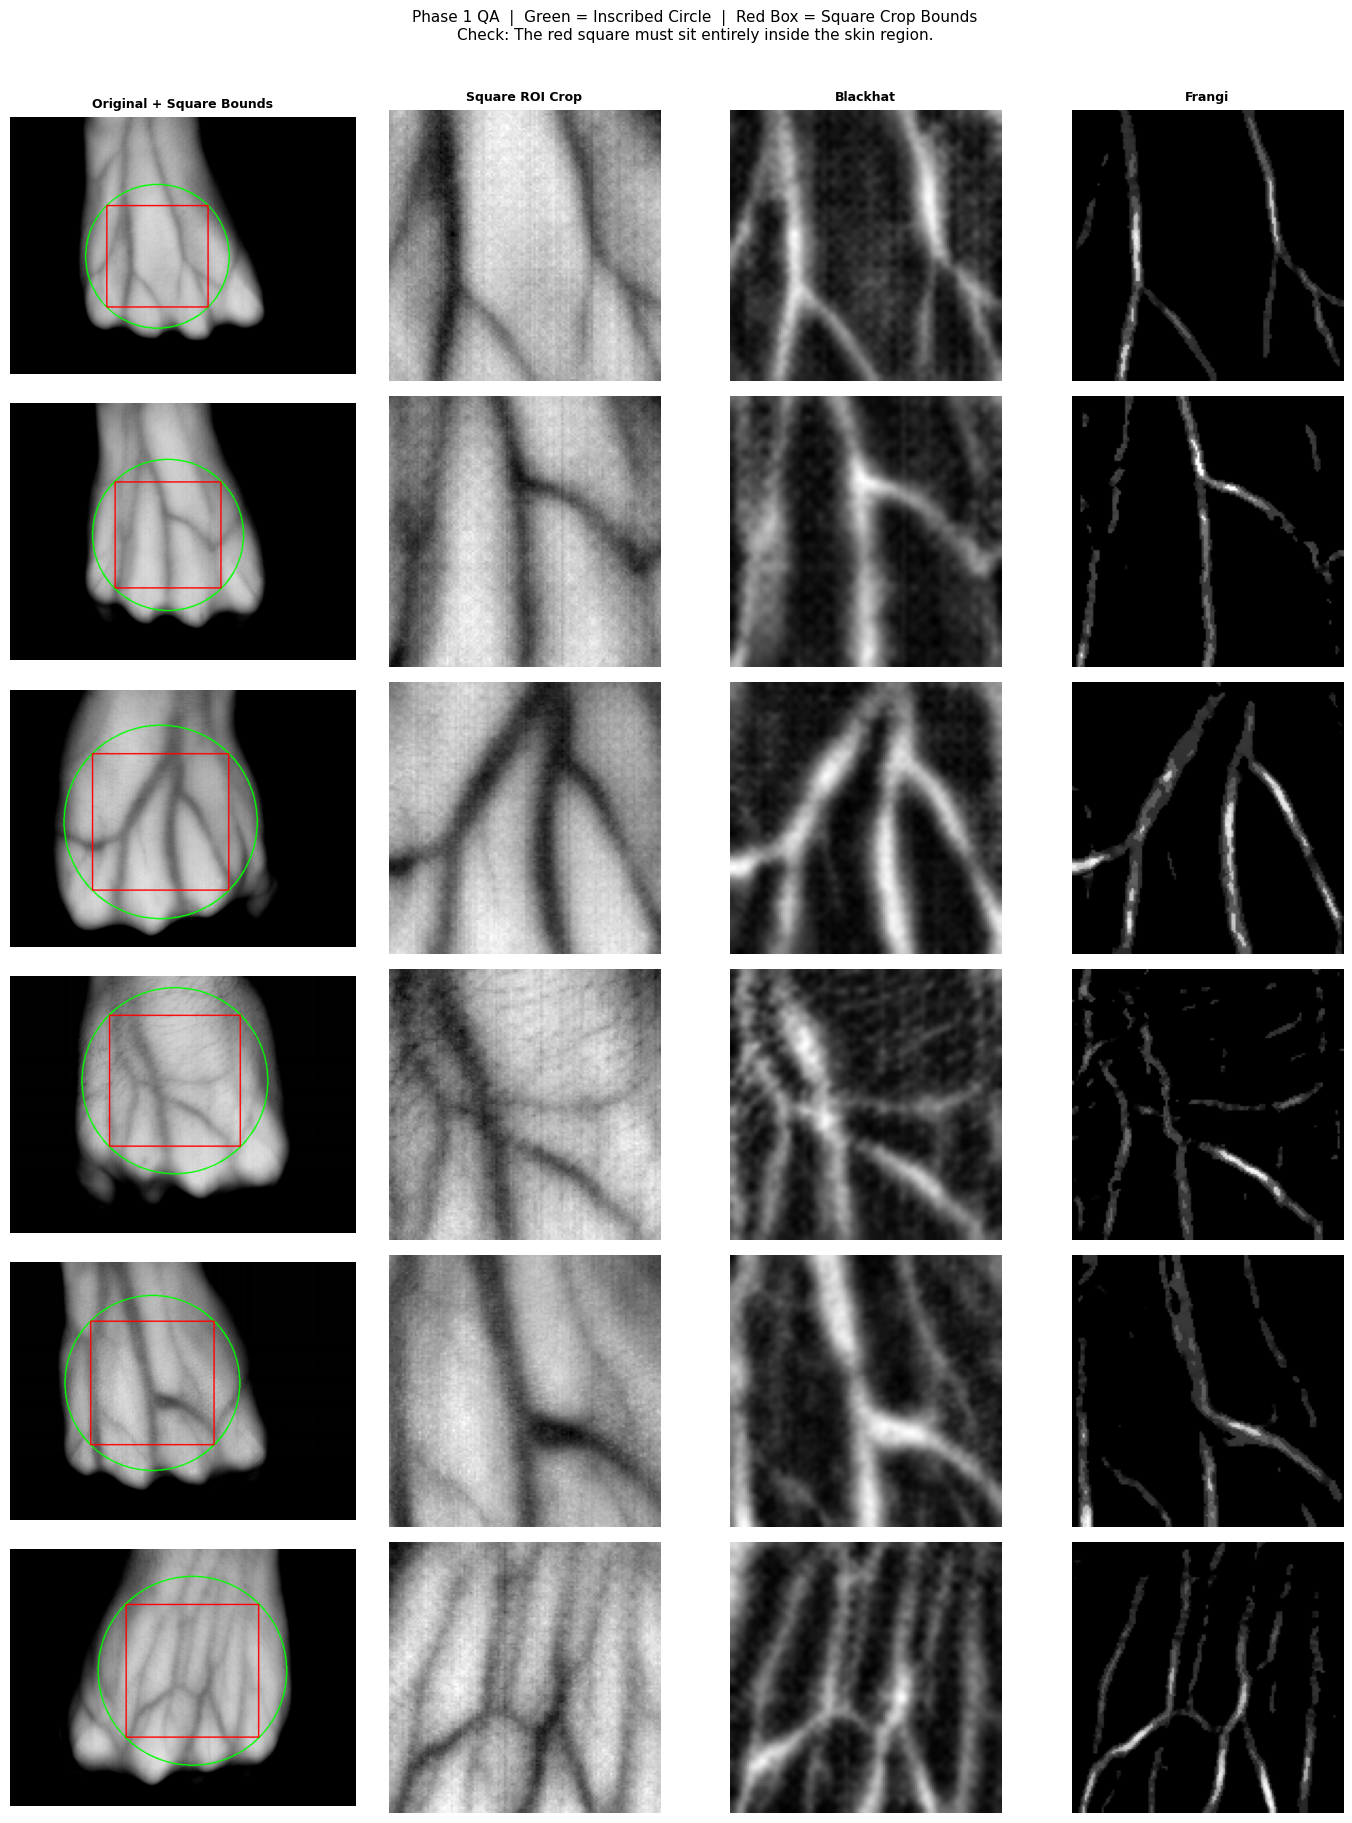

In [19]:
# =========================================================================
# CELL 3: QA — TEST INSCRIBED SQUARE ON 6 IMAGES BEFORE FULL RUN
# =========================================================================

folder  = f'{DATASET_ROOT}/DorsalHandVeins_DB1_png'
files   = sorted([f for f in os.listdir(folder) if f.endswith('.png')])
samples = random.sample(files, 6)

fig, axes = plt.subplots(6, 4, figsize=(14, 18))
col_labels = ['Original + Square Bounds', 'Square ROI Crop', 'Blackhat', 'Frangi']

for row, fname in enumerate(samples):
    gray   = cv2.imread(f'{folder}/{fname}', cv2.IMREAD_GRAYSCALE)
    result = extract_square_roi(gray, debug=True)
    roi, geometry_info, success, dbg = result

    # Col 0: original with circle and inner square boundary overlay
    ax = axes[row, 0]
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    if success:
        cx, cy, r, half_s = geometry_info
        # Draw the max circle in green
        cv2.circle(vis, (cx, cy), r, (0, 255, 0), 2)
        # Draw the target square crop boundary in red
        cv2.rectangle(vis, (cx - half_s, cy - half_s), (cx + half_s, cy + half_s), (0, 0, 255), 2)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    if row == 0: ax.set_title(col_labels[0], fontsize=9, fontweight='bold')
    ax.set_ylabel(fname[:18], fontsize=6, rotation=0, labelpad=65)

    if not success:
        for c in range(1, 4):
            axes[row, c].text(0.5, 0.5, 'FAILED', ha='center', va='center',
                               color='red', transform=axes[row, c].transAxes)
            axes[row, c].axis('off')
        continue

    # Clean display of updated edge-to-edge patches
    axes[row, 1].imshow(roi, cmap='gray'); axes[row, 1].axis('off')
    axes[row, 2].imshow(enhance_blackhat(roi), cmap='gray'); axes[row, 2].axis('off')
    axes[row, 3].imshow(enhance_frangi(roi), cmap='gray'); axes[row, 3].axis('off')
    if row == 0:
        for c, lbl in enumerate(col_labels[1:], 1):
            axes[row, c].set_title(lbl, fontsize=9, fontweight='bold')

plt.suptitle('Phase 1 QA  |  Green = Inscribed Circle  |  Red Box = Square Crop Bounds\n'
             'Check: The red square must sit entirely inside the skin region.',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase1_qa.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
import shutil
from pathlib import Path

# Paths to clear out
dirs_to_wipe = [PROCESSED_DIR, STRUCTURED_DIR, f'{OUTPUT_ROOT}/features']

for d in dirs_to_wipe:
    if os.path.exists(d):
        print(f"Wiping: {d}")
        shutil.rmtree(d)
        # Recreate an empty directory so the pipeline doesn't crash
        Path(d).mkdir(parents=True, exist_ok=True)

print("✨ Workspace is clean and ready for the square ROI run!")

Wiping: /content/drive/MyDrive/DorsalVeinProject/processed_v2
Wiping: /content/drive/MyDrive/DorsalVeinProject/dataset_structured
Wiping: /content/drive/MyDrive/DorsalVeinProject/features
✨ Workspace is clean and ready for the square ROI run!


In [ ]:
# =========================================================================
# CELL 4: PROCESS ALL IMAGES + BUILD 276-CLASS STRUCTURE
# =========================================================================
import time

manifest = []
failed   = []

for db in DBS:
    folder = f'{DATASET_ROOT}/DorsalHandVeins_DB{db}_png'
    if not os.path.exists(folder):
        print(f'⚠ Not found: {folder}'); continue

    files = sorted(f for f in os.listdir(folder) if f.endswith('.png'))
    print(f'\nProcessing DB{db}: {len(files)} images ...')
    t0 = time.time()

    for i, fname in enumerate(files):
        m = re.match(rf'person_(\d+)_db{db}_([LR])(\d+)\.png', fname)
        if not m: continue
        pid, hand, ses = m.group(1), m.group(2), m.group(3)

        # Output paths
        proc_dir = Path(PROCESSED_DIR) / f'db{db}' / f'person_{pid}'
        proc_dir.mkdir(parents=True, exist_ok=True)
        base        = fname.replace('.png', '')
        bh_path     = str(proc_dir / f'{base}_blackhat.png')
        roi_path    = str(proc_dir / f'{base}_roi.png')
        frangi_path = str(proc_dir / f'{base}_frangi.png')

        # Structured structural directory paths
        class_label = f'{pid}{hand}'
        class_dir   = Path(STRUCTURED_DIR) / class_label
        class_dir.mkdir(exist_ok=True)
        struct_path = str(class_dir / f'{class_label}{ses}.png')

        # Direct verification skip
        if os.path.exists(bh_path) and os.path.exists(struct_path):
            manifest.append(dict(
                person=pid, hand=hand, session=ses, db=db,
                class_label=class_label,
                roi_path=roi_path, blackhat_path=bh_path,
                frangi_path=frangi_path, struct_path=struct_path
            ))
            continue

        # Processing execution
        result = process_image(f'{folder}/{fname}')
        if result is None:
            failed.append(fname); continue

        cv2.imwrite(roi_path,     result['roi'])
        cv2.imwrite(bh_path,      result['blackhat'])
        cv2.imwrite(frangi_path,  result['frangi'])
        cv2.imwrite(struct_path,  result['blackhat'])  # Training uses clean blackhat file

        manifest.append(dict(
            person=pid, hand=hand, session=ses, db=db,
            class_label=class_label,
            roi_path=roi_path, blackhat_path=bh_path,
            frangi_path=frangi_path, struct_path=struct_path
        ))

        if (i+1) % 200 == 0:
            elapsed   = time.time() - t0
            remaining = elapsed/(i+1) * (len(files)-i-1)
            print(f'  {i+1}/{len(files)}  |  {elapsed/60:.1f}m elapsed  |  {remaining/60:.1f}m remaining')

    print(f'  ✓ DB{db} completion achieved.')

# Save updated data manifest
with open(f'{OUTPUT_ROOT}/manifest_v2.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print(f'\n── Summary ──────────────────────────────────')
print(f'  Processed : {len(manifest)}')
print(f'  Failed    : {len(failed)}')
print(f'  Classes   : {len(set(r["class_label"] for r in manifest))}')


Processing DB1: 1104 images ...
  200/1104  |  2.8m elapsed  |  12.6m remaining
  400/1104  |  6.0m elapsed  |  10.5m remaining
  600/1104  |  8.9m elapsed  |  7.5m remaining
  800/1104  |  11.5m elapsed  |  4.4m remaining
  1000/1104  |  14.1m elapsed  |  1.5m remaining
  ✓ DB1 completion achieved.

Processing DB2: 678 images ...
  200/678  |  2.6m elapsed  |  6.3m remaining
  400/678  |  5.3m elapsed  |  3.7m remaining
  600/678  |  7.8m elapsed  |  1.0m remaining
  ✓ DB2 completion achieved.

── Summary ──────────────────────────────────
  Processed : 1782
  Failed    : 0
  Classes   : 276
